In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
# import cv2
import random
import torch
from pt_to_api.mnist import SimpleMNIST
from pt_to_api.model_to_json import model_to_json
from pt_to_api.utils import show_single_channel_red_green_black as S

In [3]:
PUBLIC_FOLDER = Path("/Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public")

In [4]:
# with open
import json
# print(json.dumps(, indent=2))

o = model_to_json(SimpleMNIST(), (1, 1, 28, 28))
# with open(PUBLIC_FOLDER / "example-model.json", "w") as f:
#     json.dump(o, f, indent=2)
o

{'nodes': [{'id': 'x', 'type': 'Input', 'params': {}, 'shape': [1, 1, 28, 28]},
  {'id': 'layers.0',
   'type': 'Conv2d',
   'params': {'in_channels': 1,
    'out_channels': 8,
    'kernel_size': (3, 3),
    'stride': (2, 2),
    'padding': (1, 1)},
   'shape': [1, 8, 14, 14]},
  {'id': 'layers.1', 'type': 'ReLU', 'params': {}, 'shape': [1, 8, 14, 14]},
  {'id': 'layers.2',
   'type': 'Conv2d',
   'params': {'in_channels': 8,
    'out_channels': 16,
    'kernel_size': (3, 3),
    'stride': (2, 2),
    'padding': (1, 1)},
   'shape': [1, 16, 7, 7]},
  {'id': 'layers.3', 'type': 'ReLU', 'params': {}, 'shape': [1, 16, 7, 7]},
  {'id': 'layers.4', 'type': 'Flatten', 'params': {}, 'shape': [1, 784]},
  {'id': 'layers.5', 'type': 'Linear', 'params': {}, 'shape': [1, 10]},
  {'id': 'output', 'type': 'Output', 'params': {}, 'shape': []}],
 'edges': [{'source': 'x', 'target': 'layers.0'},
  {'source': 'layers.0', 'target': 'layers.1'},
  {'source': 'layers.1', 'target': 'layers.2'},
  {'source'

In [5]:
from pt_to_api.persist.activation_processor_outputs import dump_coordinates_to_files
from pt_to_api.persist.contribs_processor_outputs import dump_contribs_to_files
from pt_to_api.mnist import SimpleMNIST, get_contribs_for_inp_vectorized
from pt_to_api.capture import get_model_internals
from pt_to_api.activation_processor import process_activations_to_coordinates


model = SimpleMNIST()
model.load_state_dict(torch.load("../data/model.pt"))
inp = torch.load("../data/first-input-tens.pt", weights_only=False).to("cpu")

[<Axes: >]

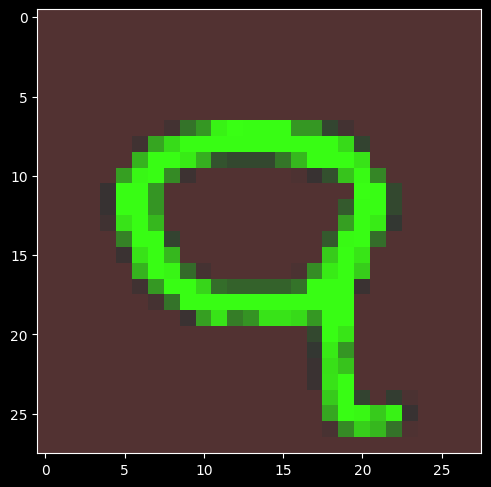

In [6]:
S([inp.detach()[0][0]])

In [7]:
model.to("cpu")
activations, parameters = get_model_internals(model, inp)
activations.keys()

dict_keys(['layers.0', 'layers.0.out_0.in_0', 'layers.0.out_0.in_0.input', 'layers.0.out_1.in_0', 'layers.0.out_1.in_0.input', 'layers.0.out_2.in_0', 'layers.0.out_2.in_0.input', 'layers.0.out_3.in_0', 'layers.0.out_3.in_0.input', 'layers.0.out_4.in_0', 'layers.0.out_4.in_0.input', 'layers.0.out_5.in_0', 'layers.0.out_5.in_0.input', 'layers.0.out_6.in_0', 'layers.0.out_6.in_0.input', 'layers.0.out_7.in_0', 'layers.0.out_7.in_0.input', 'layers.1', 'layers.2', 'layers.2.out_0.in_0', 'layers.2.out_0.in_0.input', 'layers.2.out_0.in_1', 'layers.2.out_0.in_1.input', 'layers.2.out_0.in_2', 'layers.2.out_0.in_2.input', 'layers.2.out_0.in_3', 'layers.2.out_0.in_3.input', 'layers.2.out_0.in_4', 'layers.2.out_0.in_4.input', 'layers.2.out_0.in_5', 'layers.2.out_0.in_5.input', 'layers.2.out_0.in_6', 'layers.2.out_0.in_6.input', 'layers.2.out_0.in_7', 'layers.2.out_0.in_7.input', 'layers.2.out_1.in_0', 'layers.2.out_1.in_0.input', 'layers.2.out_1.in_1', 'layers.2.out_1.in_1.input', 'layers.2.out_1.i

In [8]:
# dump done
coordinate_data = process_activations_to_coordinates(activations, parameters, model)
dump_coordinates_to_files(coordinate_data, PUBLIC_FOLDER / "activations")
[k for k in coordinate_data.keys() if k.startswith("layers.2.out_0")]
coordinate_data["layers.2.out_0"]["layer_name"]

Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/activations/layers.0.out_0.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/activations/layers.0.out_1.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/activations/layers.0.out_2.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/activations/layers.0.out_3.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/activations/layers.0.out_4.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/activations/layers.0.out_5.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/activations/layers.0.out_6.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/activations/layers.0.out_7.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/activa

'layers.2'

In [9]:
model

SimpleMNIST(
  (layers): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=784, out_features=10, bias=True)
  )
)

In [10]:
from pt_to_api.contrib_processor import process_contribs_to_coordinates
from pt_to_api.utils import get_ratios_for_labels
contribs, _, _ = get_contribs_for_inp_vectorized(inp, model, get_ratios_for_labels([9]), "layers.5", "cpu")
contrib_coordinates = process_contribs_to_coordinates(contribs, 0)
dump_contribs_to_files(contrib_coordinates, PUBLIC_FOLDER / "saliency_map")
contrib_coordinates.keys()

Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/saliency_map/layers.5.out_0.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/saliency_map/layers.5.out_1.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/saliency_map/layers.5.out_2.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/saliency_map/layers.5.out_3.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/saliency_map/layers.5.out_4.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/saliency_map/layers.5.out_5.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/saliency_map/layers.5.out_6.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/saliency_map/layers.5.out_7.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/publi

dict_keys(['layers.5.out_0', 'layers.5.out_1', 'layers.5.out_2', 'layers.5.out_3', 'layers.5.out_4', 'layers.5.out_5', 'layers.5.out_6', 'layers.5.out_7', 'layers.5.out_8', 'layers.5.out_9', 'layers.3.out_0', 'layers.3.out_1', 'layers.3.out_2', 'layers.3.out_3', 'layers.3.out_4', 'layers.3.out_5', 'layers.3.out_6', 'layers.3.out_7', 'layers.3.out_8', 'layers.3.out_9', 'layers.3.out_10', 'layers.3.out_11', 'layers.3.out_12', 'layers.3.out_13', 'layers.3.out_14', 'layers.3.out_15', 'layers.2.out_0', 'layers.2.out_1', 'layers.2.out_2', 'layers.2.out_3', 'layers.2.out_4', 'layers.2.out_5', 'layers.2.out_6', 'layers.2.out_7', 'layers.2.out_8', 'layers.2.out_9', 'layers.2.out_10', 'layers.2.out_11', 'layers.2.out_12', 'layers.2.out_13', 'layers.2.out_14', 'layers.2.out_15', 'layers.1.out_0', 'layers.1.out_1', 'layers.1.out_2', 'layers.1.out_3', 'layers.1.out_4', 'layers.1.out_5', 'layers.1.out_6', 'layers.1.out_7', 'layers.2.out_0.in_0', 'layers.2.out_0.in_1', 'layers.2.out_0.in_2', 'layers.

In [11]:
contrib_coordinates['layers.2.out_3.in_5']['layer_name']

'layers.2'

In [12]:
from pt_to_api.weights_processor import process_model_weights_to_coordinates
model_coordinates = process_model_weights_to_coordinates(model)

In [13]:
model_coordinates["layers.0.out_0.in_0"]["layer_name"]

'layers.0'

In [14]:
from pt_to_api.persist.weights_processor_outputs import dump_weights_to_files
dump_weights_to_files(model_coordinates, PUBLIC_FOLDER / "weights")

Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/weights/layers.0.out_0.in_0.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/weights/layers.0.out_0.bias.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/weights/layers.0.out_1.in_0.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/weights/layers.0.out_1.bias.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/weights/layers.0.out_2.in_0.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/weights/layers.0.out_2.bias.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/weights/layers.0.out_3.in_0.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/public/weights/layers.0.out_3.bias.json
Saved: /Users/hariomnarang/Desktop/personal/hiccup-ide/frontend/neural-viz/publi